# Black Scholes valuation methods

[*Black Scholes model WIKI*](https://en.wikipedia.org/wiki/Black%E2%80%93Scholes_model). 


The purpose of this notebook is to review the most common algorithms and implement them numerically. 





Recall that the value of the hedging portfolio:

$$
V_t(t) = \mathbb{E}^Q\left[ e^{-r(T-t)} f(S_T)/F_t \right] \quad
$$

where :  
-  Q : Risk-neutral probability measure


<a id='sec1'></a>
## European option

Under the Black-Scholes (BS) model, the best method to price a vanilla European option is to use the [BS closed formula](https://en.wikipedia.org/wiki/Black%E2%80%93Scholes_model).

Case of Call : $f(S_T) = (S_T - K)^+ $

The **BS formula** for a call is:

$$ C(t,T,S,K,r,\sigma) = S \, N(d_1) - K e^{-r(T-t)} N(d_2) $$

with 

$$ d_1 = \frac{1}{\sigma \sqrt{T-t}} \biggl[ \log \biggl( \frac{S}{K} \biggr) + \biggl(r + \frac{\sigma^2}{2} \biggr) (T-t) \biggr] \quad \text{and} \quad d_2 = d_1 - \sigma \sqrt{T-t} $$

   
The formula for a put is similar and can be found in the wiki page.

The value of an option can be  computed as the discounted expectation of a future payoff in this way:
### 1st method:

##### Procedure

Recall that:

$$
V_t(t) = \mathbb{E}^Q\left[ e^{-r(T-t)} f(S_T)/F_t \right] \quad
$$

$$
= \mathbb{E}^Q\left[ e^{-r(T-t)} f\left(S_t \frac{S_T}{S_t}\right) / F_t \right] \quad t \text{ S_t is markov}
$$

As the dynamic of \( S_t \) under \( Q \) is given by:

$$
dS_t = r_t S_t dt + \sigma S_t dB_t \quad \text{under } Q.
$$

$$
So: \quad S_t = s_0 \exp\left( (r - \frac{\sigma^2}{2}) t + \sigma B_t \right), \quad t \in [0, T]
$$

Then:

$$
V_t(\phi) = \mathbb{E}^Q\left[ e^{-r(T-t)} f\left(s_t e^{\sigma(B_T - B_t) + (2 - \sigma^2_{t})(T-t)}\right) / F_t \right]
$$
$$
S_t is ( \mathcal{F}_t )-measurable\\
 \sigma(B_T - B_t) \perp\!\!\!\perp \mathcal{F}_t \
$$
##### Compact Form
$$
V_t = F(t,S_t) \text{ where   } F(t,x) = \mathbb{E}^\Theta\left[e^{-r(T-t)}f\left(xe^{\sigmaΔB + (r-\frac{\sigma^2}{2})Δt}\right)\right]
$$
where :  $ΔB = B_T-B_t$, $Δt = T-t$
-  Q : Risk-neutral probability measure.

The pricing function satisfies: for a Call

$$
F(t,x) = \mathbb{E}^{Q}\left[e^{-r(T-t)}\left(xe^{\sigma(B_{T}-B_{t}) + \left(r - \frac{\sigma^{2}}{2}\right)(T-t)} - K\right)_{+}\right]
$$

##### Brownian Motion Properties:
$$
B_{T}-B_{t} \triangleq B_{T-t} \triangleq \mathcal{N}(0,T-t) \triangleq \sqrt{T-t}\,G
$$
where:
$$
G \sim \mathcal{N}(0, 1)
$$

##### Integral Representation:
$$
F(t,x) = e^{-r(T-t)}\int_{\mathbb{R}}\left(xe^{\sigma\sqrt{T-t}\,y} + \left(r - \frac{\sigma^2}{2}\right)(T-t) - K\right)_{+} \frac{e^{-\frac{y^{2}}{2}}}{\sqrt{2\pi}} dy
$$

##### Exercise Condition:
$$
\left\{y \ge \frac{1}{\sigma\sqrt{T-t}}\left(\ln\left(\frac{K}{x}\right) - \left(r - \frac{\sigma^2}{2}\right)(T-t)\right) =: d_{-}\right\}
$$

##### Final Decomposition:
$$
\begin{aligned}
F(t,x) &= xe^{-r(T-t)}\int_{d}^{+\infty} e^{\sigma\sqrt{T-t}\,y - \frac{\sigma^2}{2}(T-t)} \frac{e^{-\frac{y^{2}}{2}}}{\sqrt{2\pi}} dy \\
&\quad - Ke^{-r(T-t)}\int_{d}^{+\infty} \frac{e^{-\frac{y^{2}}{2}}}{\sqrt{2\pi}} dy
\end{aligned}
$$
$$
x\int_{0}^{+\infty}e^{-\frac{1}{2}\left(\frac{y}{\sigma}-\sigma\sqrt{T-t}\right)^{2}}\frac{dy}{\sqrt{2\pi}} - e^{-r(T-t)}K\,\mathbb{P}(G > d)
$$

##### Change of Variable:
Applying $y' = y - \sigma\sqrt{T-t}$:

$$
F(t,x) = x\int_{d-\sigma\sqrt{T-t}}^{+\infty}\frac{e^{-\frac{y'^{2}}{2}}}{\sqrt{2\pi}}dy' - e^{-r(T-t)}K\,\mathbb{P}(G > d)
$$

##### Probability Notation:
$$
= x\,\mathbb{P}(G \geq d - \sigma\sqrt{T-t}) - e^{-r(T-t)}K\,\mathbb{P}(G > d)
$$

##### Symmetry of Normal Distribution:
Since $G \sim \mathcal{N}(0,1) G =-G$:

$$
F(t,x) = x\,\mathbb{P}(G \leq -d + \sigma\sqrt{T-t}) - e^{-r(T-t)}K\,\mathbb{P}(G \leq -d)
$$

##### Standard Black-Scholes Form:
$$
= x\,N(\underbrace{d + \sigma\sqrt{T-t}}_{:=d_1}) - e^{-r(T-t)}KN(\underbrace{-d}_{:=d_2})
$$

Where:
- $N(\cdot)$ is the standard normal CDF
- $d_1 = \frac{\ln(x/K) + (r + \sigma^2/2)(T-t)}{\sigma\sqrt{T-t}}$
- $d_2 = d_1 - \sigma\sqrt{T-t}$

#### Comment:
Usually in statistics random variables are indicated by capital letters, and non-random variables are indicated with small letters. However, it is very common to indicate the stock price in the Black-Scholes formula with a capital letter e.g [wiki notation](https://en.wikipedia.org/wiki/Black%E2%80%93Scholes_model#Notation).

### 2nd Method: (without integration)
#### Let us analyze better the previous formulas



\begin{align*}
 C(s,t,K,T) &= e^{-r(T-t)} \mathbb{E}^{\mathbb{Q}}\biggl[ (S_T - K)^+ \bigg| S_t=s \biggr] \\
            &= e^{-r(T-t)} \mathbb{E}^{\mathbb{Q}}\biggl[ S_T \mathbb{1}_{S_T >K} \bigg| S_t=s \biggr] 
              - e^{-r(T-t)} \mathbb{E}^{\mathbb{Q}}\biggl[ K \mathbb{1}_{S_T >K} \bigg| S_t=s \biggr] \\
            &= e^{-r(T-t)} \mathbb{E}^{\mathbb{Q}}\biggl[ S_T \mathbb{1}_{S_T >K} \bigg| S_t=s \biggr] 
              - e^{-r(T-t)} K \, \underbrace{\mathbb{Q}\biggl[ S_T >K \bigg| S_t=s \biggr]}_{N(d_2)} \\            
\end{align*}

Let us introduce the following change of measure (under the stock numeraire):

$$ \begin{aligned}
\frac{d \tilde{\mathbb{Q}} }{ d \mathbb{Q} } &= \frac{S_T}{\mathbb{E}^\mathbb{Q}[S_T | S_t]} = \frac{S_T}{S_t e^{r(T-t)}}  \\ 
                                            &= \frac{S_t e^{(r -\frac{1}{2}\sigma^2)(T-t) + \sigma W_{T-t}} }{S_t e^{r(T-t)}} \\
                                            &=   e^{ -\frac{1}{2}\sigma^2(T-t) + \sigma W_{T-t} } \quad \text{(exponential martingale)} 
\end{aligned} $$

By [Girsanov theorem](https://en.wikipedia.org/wiki/Girsanov_theorem), under $\tilde{\mathbb{Q}}$ the driving Brownian motion has the new dynamics 

$$ \tilde{W_t} = W_t - \sigma t $$

and the corresponding stock dynamics becomes

$$\begin{aligned}
 \frac{dS_t}{S_t} &= r dt + \sigma dW_t \\
                  &= (r+\sigma^2) dt + \sigma d\tilde{W}_t 
\end{aligned}$$

The first term is

$$ \begin{aligned}
 e^{-r(T-t)} \mathbb{E}^{\mathbb{Q}}\biggl[ S_T \mathbb{1}_{S_T >K} \bigg| S_t=s \biggr] =& e^{-r(T-t)} \mathbb{E}^{\tilde{\mathbb{Q}}} 
                 \biggl[ \frac{d \mathbb{Q} }{ d \tilde{\mathbb{Q}}}  S_T \mathbb{1}_{S_T >K} \bigg| S_t=s \biggr] \\
                     =& e^{-r(T-t)} \mathbb{E}^{\tilde{\mathbb{Q}}} 
                 \biggl[ \frac{e^{r(T-t)}S_t}{S_T}  S_T \mathbb{1}_{S_T > K} \bigg| S_t=s \biggr] \\ 
                    =& \; s \, \underbrace{\tilde{\mathbb{Q}} ( S_T > K | S_t=s)}_{N(d_1)}
\end{aligned}$$

We have just seen how to interpret the terms $N(d_1)$ and $N(d_2)$. These are the risk neutral probabilities of $S_T > K$ in the stock and money market numeraires respectively.

In [1]:
S0 = 100.0  # spot stock price
K = 100.0  # strike
T = 1.0  # maturity
r = 0.1  # risk free rate
sig = 0.2  # diffusion coefficient or volatility

<a id='sec1.1'></a>
### Put-Call parity

This is an important formula [wiki page](https://en.wikipedia.org/wiki/Put%E2%80%93call_parity)

$$ Call - Put = S_0 - K e^{-rT}  $$


<a id='sec2'></a>
## Numerical integration
 

Let us compute the option prices by integrating the log-normal density:

In [4]:
import numpy as np
e_ret = np.log(S0) + (r - 0.5 * sig**2) * T  # expected return of the log-price
vol = sig * np.sqrt(T)  # standard deviation of the log-price


# log-normal density (defined above)
def log_normal(x, e_ret, vol):
    return 1 / (x * vol * np.sqrt(2 * np.pi)) * np.exp(-((np.log(x) - e_ret) ** 2) / (2 * vol**2))

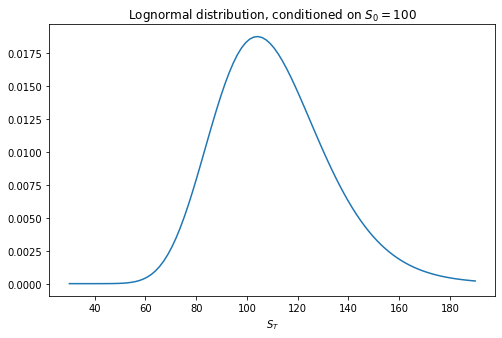

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
x = np.linspace(30, 190, 100)
plt.plot(x, log_normal(x, e_ret, vol))
plt.title("Lognormal distribution, conditioned on $S_0=100$")
plt.xlabel("$S_T$")
plt.show()

The function `log_normal(x, e_ret, vol)` defined above, corresponds to the scipy.stats function: 
```
ss.lognorm.pdf(x, vol, scale=np.exp(e_ret) ).
```

In the next calculation, I'm going to use the scipy function.    
Let us perform the integration with the `scipy.integrate` function [quad](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html):

In [10]:
import scipy.stats as ss
from scipy.integrate import quad
def integrand_LN(S, strike, e_ret, vol, payoff):
    if payoff == "call":
        return (S - strike) * ss.lognorm.pdf(S, vol, scale=np.exp(e_ret))
    elif payoff == "put":
        return (strike - S) * ss.lognorm.pdf(S, vol, scale=np.exp(e_ret))


call = quad(integrand_LN, K, np.inf, args=(K, e_ret, vol, "call"))[0] * np.exp(-r * T)
put = quad(integrand_LN, 0, K, args=(K, e_ret, vol, "put"))[0] * np.exp(-r * T)

print("Call price: {} \nPut price: {} ".format(call, put))

Call price: 13.269676584660926 
Put price: 3.753418388256828 


The put option payoff $(K-S_T)^+$ is positive for $S_T < K$.    
- In the call case, the integration is from $K$ to $\infty$.
- In the put case, the integration is from $0$ to $K$.

What if we use the change of measure proposed above?  In this way the integrations are simpler.    
Let us compute $\tilde{\mathbb{Q}}( S_T > K )$ and $\mathbb{Q}( S_T > K )$.

In [11]:
# expected return of the log-price under the new measure
e_ret_1 = np.log(S0) + (r + 0.5 * sig**2) * T

Q1 = quad(lambda S: ss.lognorm.pdf(S, vol, scale=np.exp(e_ret_1)), K, np.inf)[0]
print("Risk neutral probability under stock numeraire,\n Q1 =", Q1)
Q2 = quad(lambda S: ss.lognorm.pdf(S, vol, scale=np.exp(e_ret)), K, np.inf)[0]
print("Risk neutral probability under money market numeraire,\n Q2 =", Q2)

print("BS call price: ", S0 * Q1 - K * np.exp(-r * T) * Q2)

Risk neutral probability under stock numeraire,
 Q1 = 0.7257468822499274
Risk neutral probability under money market numeraire,
 Q2 = 0.6554217416103069
BS call price:  13.269676584662555


It is quite common to compute the Black-Scholes formula using $N(d_1)$ and $N(d_2)$.   
The reason is that the cumulative function of the standard Normal distribution is more accessible.
For completeness, let me recall that if $X_T$ is a Normal random variable, then $S_T = S_0 e^{X_T}$ is Log-Normal. Therefore we have:

$$ \mathbb{Q}( S_T > K ) = \mathbb{Q}\biggl( S_0 e^{X_T} > K \biggr) = \mathbb{Q}\biggl( X_T > \log \frac{K}{S_0} \biggr). $$

This permits to use the Normal cumulative function.

<a id='sec3'></a>
## Monte Carlo method

I'm going to simulate the random variables: 

$$ S_T^i = S_0 e^{(r -\frac{1}{2}\sigma^2)T + \sigma W_{T}^i} $$

for $1 \leq i \leq N$.    
Then use the approximation for a call option:

$$ \mathbb{E}^{\mathbb{Q}}\biggl[ (S_T - K)^+ \bigg| S_0 \biggr] \; 
\approx \; \frac{1}{N} \sum_{i=1}^N (S_T^i - K)^+
$$

For a put option I use this payoff $(K - S_T )^+$ inside the expectation.

In [12]:
np.random.seed(seed=44)  # seed for random number generation
N = 10000000  # Number of random variables

W = ss.norm.rvs((r - 0.5 * sig**2) * T, np.sqrt(T) * sig, N)
S_T = S0 * np.exp(W)

call = np.mean(np.exp(-r * T) * np.maximum(S_T - K, 0))
put = np.mean(np.exp(-r * T) * np.maximum(K - S_T, 0))
call_err = ss.sem(np.exp(-r * T) * np.maximum(S_T - K, 0))  # standard error
put_err = ss.sem(np.exp(-r * T) * np.maximum(K - S_T, 0))  # standard error

In [14]:
print("Call price: {}, with error: {}".format(call, call_err))
print("Put price: {}, with error: {}".format(put, put_err))

Call price: 13.26333800663666, with error: 0.005093638687208466
Put price: 3.7553894006350084, with error: 0.002214066662789331
